# Accessing and using OBIS species distribution models (Python)

This notebook shows the same workflow as [access_sdm_aws.ipynb](access_sdm_aws.ipynb), but using Python instead of R. Predictions and the raw (quality-controlled) data, as well as additional files (e.g. model metrics), are available through both the mapping platform and AWS S3.

To explore the files available, go to https://obis-maps.s3.amazonaws.com/index.html

## Folder structure

Outputs stored in this bucket always follow the same standard structure. File names will always contain at least two components:

`taxonid=[AphiaID]`: identify the taxon
`model=[Model run acronym]`: identify the modelling exercise

Additional information also follows a similar syntax (inspired by the hive format) and is identified by "[the parameter]=[the value]". For example, a prediction file for a species looks like this:

`taxonid=135185_model=mpaeu_method=maxent_scen=ssp126_dec100_cog.tif`

`method` is the algorithm used for the model and `scen` the scenario and period of the prediction. In this case `_cog` simply indicates that the output is COG (cloud-optimized GeoTIFF) optimized.

A species folder has the following structure:

```
├── figures                    : Plots for quick exploration of results
├── metrics                    : All metrics and additional information (e.g. CV metrics, response curves, etc.)
├── models                     : RDS files containing the fitted models, ready for predicting in new data
├── predictions                : The TIF files with predictions
│
├── ..._what=fitocc.parquet    : Occurrence points used to fit the model
└── ..._what=log.json          : The log file containing all model fit details
```

Here we will focus on the **predictions** folder, but you can learn more about the whole structure in the [OBIS SDM documentation](https://iobis.github.io/mpaeu_docs/datause.html).

## Loading a prediction

Let's explore one prediction for the species *Sebastes norvegicus* ([AphiaID 151324](https://obis.org/taxon/151324)) - the same species used in the R notebook.

The easiest way to work with raster (GeoTIFF) files in Python is using the `rasterio` package (alternatively, you can work with `rioxarray`). GDAL's `/vsicurl/` prefix lets `rasterio` stream a Cloud-Optimized GeoTIFF straight from S3, without downloading the whole file first:

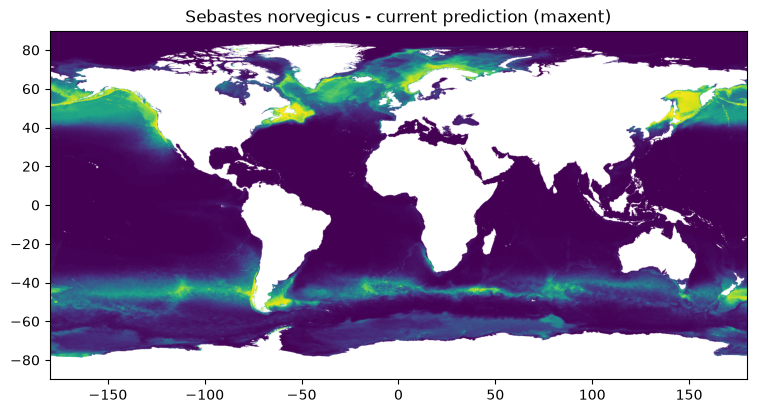

In [1]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

aws_path = "https://obis-maps.s3.amazonaws.com/sdm/species"
species = 151324
model = "mpaeu"   # acronym identifying model realization
algo = "maxent"   # SDM method

current_url = (
    f"/vsicurl/{aws_path}/taxonid={species}/model={model}/predictions/"
    f"taxonid={species}_model={model}_method={algo}_scen=current_cog.tif"
)

with rasterio.open(current_url) as src:
    current = src.read(1, masked=True)
    current_transform = src.transform

fig, ax = plt.subplots(figsize=(9, 5))
show(current, transform=current_transform, ax=ax, cmap="viridis")
ax.set_title("Sebastes norvegicus - current prediction (maxent)")
plt.show()

All predictions folders always include a mask file (`..._what=mask_cog.tif`). It is a multiband raster, with each band being a different mask. We plot here the "fit_region" band, and overlay the occurrence records used to fit the model (stored as a GeoParquet file, `..._what=fitocc.parquet`).

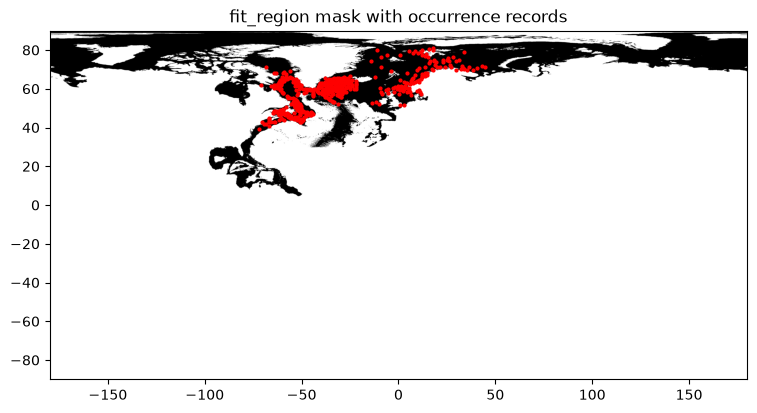

In [2]:
import io

import numpy as np
import pandas as pd
import requests

mask_url = (
    f"/vsicurl/{aws_path}/taxonid={species}/model={model}/predictions/"
    f"taxonid={species}_model={model}_what=mask_cog.tif"
)

with rasterio.open(mask_url) as src:
    band_index = src.descriptions.index("fit_region") + 1
    fit_region = src.read(band_index, masked=True)
    mask_transform = src.transform

pts_url = (
    f"{aws_path}/taxonid={species}/model={model}/"
    f"taxonid={species}_model={model}_what=fitocc.parquet"
)
pts = pd.read_parquet(io.BytesIO(requests.get(pts_url).content))

fig, ax = plt.subplots(figsize=(9, 5))
show(fit_region, transform=mask_transform, ax=ax, cmap="Greys")
ax.scatter(pts["decimalLongitude"], pts["decimalLatitude"], s=4, color="red")
ax.set_title("fit_region mask with occurrence records")
plt.show()

Predictions show the relative suitability of a place, in terms of its environmental conditions. However, predictions are made for the whole globe, including areas which may not be reachable by the species. Thus, it is always advisable to mask the predictions by one of the masks provided (or by one you create based on your own knowledge/data). Here we use the "fit_region" mask shown above.

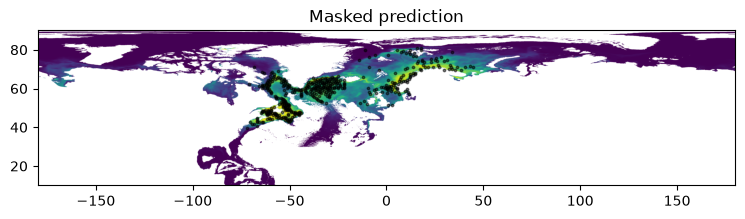

In [3]:
current_masked = np.ma.masked_where(
    (fit_region == 0) | np.ma.getmaskarray(fit_region), current
)

fig, ax = plt.subplots(figsize=(9, 5))
show(current_masked, transform=current_transform, ax=ax, cmap="viridis")
ax.scatter(pts["decimalLongitude"], pts["decimalLatitude"], s=3, color="black", alpha=0.5)
ax.set_ylim(10, 90)  # limit for better visualization
ax.set_title("Masked prediction")
plt.show()

Now that we masked the prediction, we may want to limit it to only areas that are more likely to have the species, according to a certain threshold. Here we apply the P10 threshold (i.e. the 10th percentile of suitability values at occurrence locations) to remove areas of low suitability.

Note that predictions are stored as integers (multiplied by 100) to save space, so the threshold (which is on the original 0-1 scale) also needs to be multiplied by 100 before being applied.

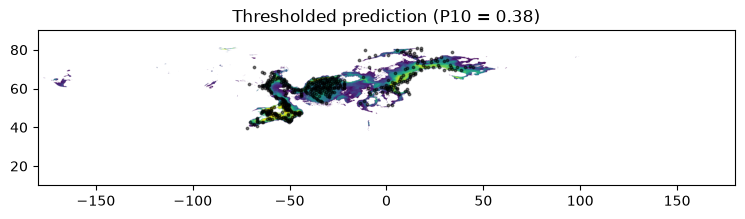

In [4]:
th_url = (
    f"{aws_path}/taxonid={species}/model={model}/metrics/"
    f"taxonid={species}_model={model}_what=thresholds.parquet"
)
thresholds = pd.read_parquet(io.BytesIO(requests.get(th_url).content))

p10 = thresholds.loc[thresholds["model"] == algo, "p10"].iloc[0] * 100

current_thresholded = np.ma.masked_where(current_masked < p10, current_masked)

fig, ax = plt.subplots(figsize=(9, 5))
show(current_thresholded, transform=current_transform, ax=ax, cmap="viridis")
ax.scatter(pts["decimalLongitude"], pts["decimalLatitude"], s=3, color="black", alpha=0.5)
ax.set_ylim(10, 90)
ax.set_title(f"Thresholded prediction (P10 = {p10 / 100:.2f})")
plt.show()

You can explore more in depth how to work with the SDMs, and specially understand the limitations of the models, in the [OBIS SDM documentation](https://iobis.github.io/mpaeu_docs/).